In [20]:
import pandas as pd

df= pd.read_csv('NFLX.csv')

In [22]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [24]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07


## Preprocessing

In [27]:
df['Date'] = pd.to_datetime(df['Date'].apply(lambda x: x.split(" ")[0]))

In [28]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
df_n = df[features].copy()

C:\Users\monir\AppData\Local\Temp\ipykernel_9996\2107194740.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fg.show()


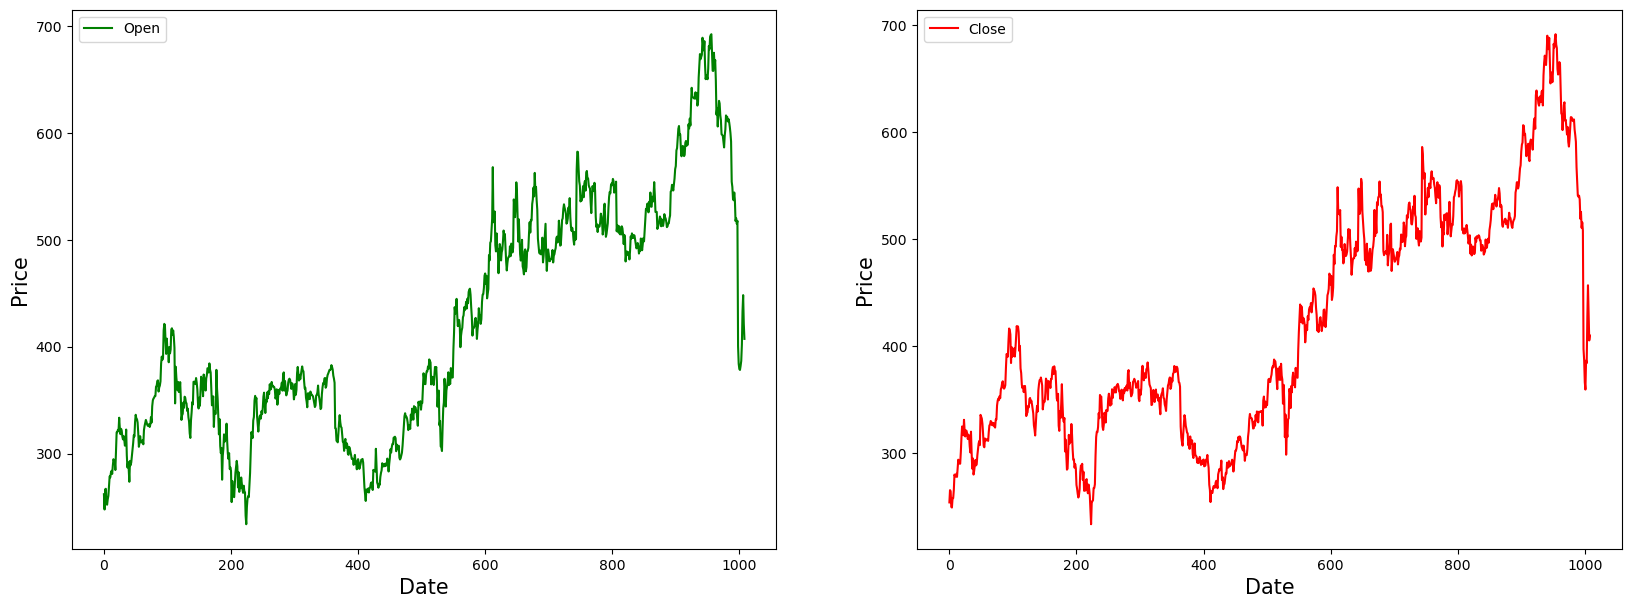

In [29]:
import numpy as np
import matplotlib.pyplot as plt
fg, ax =plt.subplots(1,2,figsize=(20,7))
ax[0].plot(df_n['Open'],label='Open',color='green')
ax[0].set_xlabel('Date',size=15)
ax[0].set_ylabel('Price',size=15)
ax[0].legend()

ax[1].plot(df_n['Close'],label='Close',color='red')
ax[1].set_xlabel('Date',size=15)
ax[1].set_ylabel('Price',size=15)
ax[1].legend()

fg.show()

In [32]:
scaler = MinMaxScaler()
df_n[features] = scaler.fit_transform(df_n[features].values)

In [33]:
df_n

,Open,High,Low,Close,Volume
0,0.061253,0.038304,0.041331,0.044516,0.186150
1,0.030059,0.035640,0.030273,0.069548,0.198264
2,0.071243,0.048408,0.072770,0.067015,0.135690
3,0.072334,0.037683,0.041265,0.035430,0.141320
4,0.043474,0.011436,0.010729,0.034053,0.272902
...,...,...,...,...,...
1004,0.366577,0.393147,0.367080,0.422140,0.327275
1005,0.434178,0.461496,0.427186,0.487648,0.370467
1006,0.467531,0.447062,0.429253,0.427251,0.228565
1007,0.409048,0.396611,0.380447,0.375090,0.151682


## Training

In [85]:
seq_length = 20  # sequence length
future_step = 5 # five days 

In [86]:
data = df_n.values

In [87]:
def create_sequences(data, seq_length, future_step):
    xs, ys = [], []
    for i in range(len(data) - seq_length - future_step):
        x = data[i:i+seq_length]
        # لو سعر الإغلاق بعد future_step أعلى من بداية sequence -> up (1) else down (0)
        y = 1 if data[i+seq_length+future_step-1, 3] > data[i, 3] else 0
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


In [88]:
X, y = create_sequences(data, seq_length, future_step)

In [89]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [91]:
#CNN-lstm model architecture 

class CNN_LSTM(nn.Module):
    def __init__(self, input_size=5, cnn_out_channels=64, lstm_hidden=, lstm_layers=128, dropout=0.4):
        super(CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, cnn_out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.lstm = nn.LSTM(cnn_out_channels, lstm_hidden, lstm_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.transpose(1,2)  # (batch, features, seq_len) for CNN
        x = self.cnn(x)
        x = x.transpose(1,2)  # (batch, seq_len', features) for LSTM
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return self.sigmoid(out).squeeze()

SyntaxError: expected default value expression (607419273.py, line 4)

In [92]:
epochs = 60
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [93]:
def calculate_accuracy(loader, model, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            predicted_labels = (preds > 0.5).float()
            correct += (predicted_labels == yb).sum().item()
            total += yb.size(0)
    return correct / total


In [ ]:
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_acc = calculate_accuracy(train_loader, model, device)
    test_acc = calculate_accuracy(test_loader, model, device)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}, "
          f"Train Acc: {train_acc*100:.2f}%, Test Acc: {test_acc*100:.2f}%")

final_train_acc = calculate_accuracy(train_loader, model, device)
final_test_acc = calculate_accuracy(test_loader, model, device)
print(f"\nFinal Training Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Test Accuracy: {final_test_acc*100:.2f}%")


Epoch 1/60, Loss: 0.6811, Train Acc: 58.96%, Test Acc: 52.28%
Epoch 2/60, Loss: 0.6743, Train Acc: 58.96%, Test Acc: 52.28%
Epoch 3/60, Loss: 0.6698, Train Acc: 63.15%, Test Acc: 70.56%
Epoch 4/60, Loss: 0.6590, Train Acc: 64.80%, Test Acc: 61.42%
Epoch 5/60, Loss: 0.6381, Train Acc: 71.66%, Test Acc: 67.51%
Epoch 6/60, Loss: 0.6107, Train Acc: 69.00%, Test Acc: 54.31%
Epoch 7/60, Loss: 0.5818, Train Acc: 70.78%, Test Acc: 54.31%
Epoch 8/60, Loss: 0.5645, Train Acc: 67.98%, Test Acc: 54.31%
Epoch 9/60, Loss: 0.5356, Train Acc: 73.19%, Test Acc: 59.39%
Epoch 10/60, Loss: 0.5180, Train Acc: 73.32%, Test Acc: 54.31%
Epoch 11/60, Loss: 0.5461, Train Acc: 68.74%, Test Acc: 54.82%
Epoch 12/60, Loss: 0.5518, Train Acc: 72.81%, Test Acc: 54.31%
Epoch 13/60, Loss: 0.5196, Train Acc: 70.14%, Test Acc: 54.31%
Epoch 14/60, Loss: 0.5024, Train Acc: 69.89%, Test Acc: 54.31%
Epoch 15/60, Loss: 0.4858, Train Acc: 76.11%, Test Acc: 54.31%
Epoch 16/60, Loss: 0.4747, Train Acc: 71.28%, Test Acc: 58.88%
E